### Ejercicio Dataset Vinos

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
file = "C:/Users/Jose Manuel/Documents/VisualStudioCode_Workspace/Repo_CEDAPY/CEDAPY_25_26/ANALISIS_DATOS_PYTHON/DATASETS/wines_SPA.csv"
df_wines = pd.read_csv(file, sep=',', engine= 'python')
df_wines.head(10)

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
0,Teso La Monja,Tinto,2013,4.9,58,Espana,Toro,995.00,Toro Red,5.0,3.0
1,Artadi,Vina El Pison,2018,4.9,31,Espana,Vino de Espana,313.50,Tempranillo,4.0,2.0
2,Vega Sicilia,Unico,2009,4.8,1793,Espana,Ribera del Duero,324.95,Ribera Del Duero Red,5.0,3.0
3,Vega Sicilia,Unico,1999,4.8,1705,Espana,Ribera del Duero,692.96,Ribera Del Duero Red,5.0,3.0
4,Vega Sicilia,Unico,1996,4.8,1309,Espana,Ribera del Duero,778.06,Ribera Del Duero Red,5.0,3.0
5,Vega Sicilia,Unico,1998,4.8,1209,Espana,Ribera del Duero,490.00,Ribera Del Duero Red,5.0,3.0
6,Vega Sicilia,Unico,2010,4.8,1201,Espana,Ribera del Duero,349.00,Ribera Del Duero Red,5.0,3.0
7,Vega Sicilia,Unico,1995,4.8,926,Espana,Ribera del Duero,810.89,Ribera Del Duero Red,5.0,3.0
8,Vega Sicilia,Unico Reserva Especial Edicion,2015,4.8,643,Espana,Ribera del Duero,345.00,Ribera Del Duero Red,5.0,3.0
9,Vega Sicilia,Unico,2011,4.8,630,Espana,Ribera del Duero,315.00,Ribera Del Duero Red,5.0,3.0


In [4]:
print(df_wines.shape)

(7500, 11)


- Vemos que el dataset tiene un total de 7500 registros en 11 columnas.


In [5]:
df_wines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   winery       7500 non-null   object 
 1   wine         7500 non-null   object 
 2   year         7498 non-null   object 
 3   rating       7500 non-null   float64
 4   num_reviews  7500 non-null   int64  
 5   country      7500 non-null   object 
 6   region       7500 non-null   object 
 7   price        7500 non-null   float64
 8   type         6955 non-null   object 
 9   body         6331 non-null   float64
 10  acidity      6331 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 644.7+ KB


- Podemos observar el tipo de datos viendo los que son númericos de los que son objetos.
- Se observa también de que las columnas tipo, cuerpo y acidez presentan bastantes datos que en principio parecen nulos

In [6]:
null_type = df_wines['type'].isnull().sum()
null_body = df_wines['body'].isnull().sum()
null_acidity = df_wines['acidity'].isnull().sum()
print(f"Nulos de tipo: {null_type}\nNulos de cuerpo: {null_body}\nNulos de acidez: {null_acidity}")

Nulos de tipo: 545
Nulos de cuerpo: 1169
Nulos de acidez: 1169


In [7]:
df_wines.describe()

,rating,num_reviews,price,body,acidity
count,7500.000000,7500.000000,7500.000000,6331.000000,6331.000000
mean,4.254933,451.109067,60.095822,4.158427,2.946612
std,0.118029,723.001856,150.356676,0.583352,0.248202
min,4.200000,25.000000,4.990000,2.000000,1.000000
25%,4.200000,389.000000,18.900000,4.000000,3.000000
50%,4.200000,404.000000,28.530000,4.000000,3.000000
75%,4.200000,415.000000,51.350000,5.000000,3.000000
max,4.900000,32624.000000,3119.080000,5.000000,3.000000


- Podemos ver que hay una gran desviación entre los precios donde el mínimo esta en 5€ y el máximo en 3.119€ lo que propicia que la media no sea muy representativa. Habra que mirar como estan distribuidos eso precios.
- Por el contrario los datos de rating, cuerpo y acidez no son tan dispersos, por lo que los datos de media son más representativos y fiables.
- Vamos a eliminar las filas que contengan valores nulos con el método dropna().

In [31]:
df_wines = df_wines.dropna(subset=['type', 'body','acidity', 'year'])
display(df_wines.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6329 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   winery       6329 non-null   object 
 1   wine         6329 non-null   object 
 2   year         6329 non-null   object 
 3   rating       6329 non-null   float64
 4   num_reviews  6329 non-null   int64  
 5   country      6329 non-null   object 
 6   region       6329 non-null   object 
 7   price        6329 non-null   float64
 8   type         6329 non-null   object 
 9   body         6329 non-null   float64
 10  acidity      6329 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 593.3+ KB


None

- Ahora tenemos 6329 registros para proceder con el estudio del dataset

In [32]:
# Configurar Pandas para mostrar todas las filas y columnas
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
wines_type = df_wines.groupby('type')['wine'].count().sort_values(ascending=False)
print(wines_type)

type
Rioja Red               2143
Ribera Del Duero Red    1277
Red                      787
Priorat Red              620
Tempranillo              267
Toro Red                 261
Sherry                   252
Albarino                 225
Mencia                   213
Rioja White               86
Pedro Ximenez             35
Grenache                  33
Cava                      29
Verdejo                   26
Monastrell                17
Montsant Red              14
Chardonnay                13
Syrah                     13
Cabernet Sauvignon        10
Sparkling                  5
Sauvignon Blanc            3
Name: wine, dtype: int64


- Con este resultado podemos ver, que los tipos de vinos más presentes en el dataset son Rioja y Ribera del Duero, mientras que el tipo de Sauvignon blanco apenas hay datos del mismo.

In [33]:
bodegas = df_wines.groupby('winery')['wine'].count().sort_values(ascending=False)
print(bodegas)

winery
Contino                                             414
Artadi                                              239
La Rioja Alta                                       228
Sierra Cantabria                                    215
Vina Pedrosa                                        207
Matarromera                                         206
Imperial                                            206
Losada                                              206
Portal del Priorat                                  204
Sei Solo                                            204
Ramon Bilbao                                        203
Campillo                                            202
Bodegas La Horra                                    202
Matsu                                               202
La Vicalanda                                        202
Conreria d'Scala Dei                                201
Mustiguillo                                         201
Mar de Frades                            

- Se observa las bodegas que presentan mayor cantidad de vinos presentes en el dataset

In [36]:
menor60 = 0
mayor60 = 0
for x in df_wines['price']:
    if(x < 60):
        menor60 +=1
    else:
        mayor60 +=1
print(f"Los vinos de menos de 60 euros son: {menor60} y los de más de 60 euros son: {mayor60}")

Los vinos de menos de 60 euros son: 4737 y los de más de 60 euros son: 1592


In [29]:
regiones = df_wines.groupby('region').count().sort_values(by= 'type',ascending=False)
print(regiones)

                                 winery  wine  year  rating  num_reviews  \
region                                                                     
Rioja                              2440  2440  2440    2440         2440   
Ribera del Duero                   1413  1413  1412    1413         1413   
Priorato                            686   686   686     686          686   
Toro                                300   300   300     300          300   
Vino de Espana                      263   263   262     263          263   
Rias Baixas                         252   252   252     252          252   
Jerez-Xeres-Sherry                  247   247   247     247          247   
Bierzo                              244   244   244     244          244   
Costers del Segre                   232   232   232     232          232   
Alicante                            233   233   233     233          233   
El Terrerazo                        222   222   222     222          222   
Castilla y L

### Gráfico variables númericas

<Axes: xlabel='acidity', ylabel='Count'>

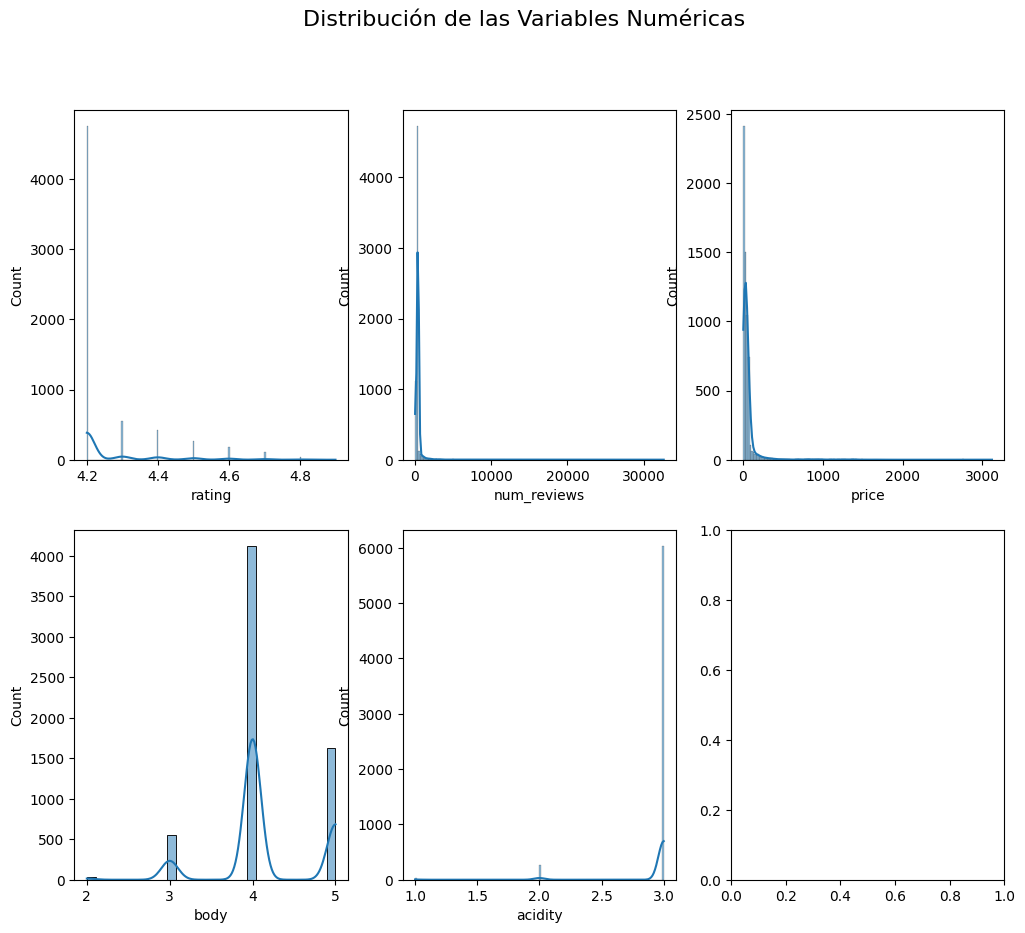

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(12, 10)) # Gráfico que contiene 4 subgráficos (2 filas x 3 columnas)
fig.suptitle('Distribución de las Variables Numéricas', fontsize=16)
sns.histplot(data=df_wines, x='rating', kde=True, ax=axes[0,0])
sns.histplot(data=df_wines, x='num_reviews', kde=True, ax=axes[0,1])
sns.histplot(data=df_wines, x='price', kde=True, ax=axes[0,2])
sns.histplot(data=df_wines, x='body', kde=True, ax=axes[1,0])
sns.histplot(data=df_wines, x='acidity', kde=True, ax=axes[1,1])

-

### Variables CATEGÓRICAS

- Creamos varios gráficos de 